# Análisis de Discretización: Tres Subyacentes Correlados

Este notebook analiza el impacto de los parámetros de discretización ($n$ y $n_\sigma$) sobre la distribución conjunta de **tres activos correlados** simulados mediante Movimiento Browniano Geométrico (MBG) multivariante.

## Estructura del notebook
1. **Simulación Monte Carlo** — Generación de trayectorias con correlación arbitraria
2. **Efecto del parámetro `n`** — Resolución de la cuadrícula de precios conjunta
3. **Efecto del parámetro `n_σ`** — Anchura del soporte de probabilidad
4. **Efecto de la correlación** — Comparación entre activos correlados e independientes

In [27]:
from quantum_cva.multi_asset.classical.probability_and_underlying.multi_asset_dynamics_utils import simulate_multi_asset_gbm
from quantum_cva.multi_asset.classical.probability_and_underlying.multi_asset_discrete_probability_utils import grid_and_prob_tensor_multiasset
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - needed for 3D projection

In [28]:
# ── Parámetros del modelo: tres activos correlados ──────────────────────────
S0    = [100.0, 50.0,  75.0]
mu    = [0.05,  0.03,  0.04]
sigma = [0.20,  0.30,  0.25]

# Matriz de correlación (simétrica, definida positiva)
rho = np.array([[1.00, 0.70, 0.40],
                [0.70, 1.00, 0.50],
                [0.40, 0.50, 1.00]])

M, T    = 3, 0.5       # pasos temporales y horizonte
N_paths = 10_000
t       = np.linspace(0.0, T, M + 1)[1:]

rng = np.random.default_rng(42)
Z   = rng.standard_normal(size=(N_paths, M, 3))

S_raw = simulate_multi_asset_gbm(
    S0=S0, mu=mu, sigma=sigma, rho=rho, t=t, Z=Z,
    antithetic=True, moment_match=False,
    replications=1, replication_seed=12345, pathwise=True,
)
# S_raw: (N_paths_eff, M, 3)
S_by_time = [S_raw[:, i, :] for i in range(S_raw.shape[1])]
terminal  = S_by_time[-1]   # (N_paths_eff, 3)

print(f"Simulación completada | N_paths_eff = {terminal.shape[0]}")
print(f"\nMedias terminales  : {terminal.mean(axis=0).round(3)}")
print(f"Sigmas terminales  : {terminal.std(axis=0).round(3)}")
print(f"\nCorrelaciones empíricas:")
print(f"  S1–S2 : {np.corrcoef(terminal[:,0], terminal[:,1])[0,1]:.3f}  (target 0.70)")
print(f"  S1–S3 : {np.corrcoef(terminal[:,0], terminal[:,2])[0,1]:.3f}  (target 0.40)")
print(f"  S2–S3 : {np.corrcoef(terminal[:,1], terminal[:,2])[0,1]:.3f}  (target 0.50)")

Simulación completada | N_paths_eff = 20000

Medias terminales  : [102.558  50.756  76.523]
Sigmas terminales  : [14.767 10.887 13.68 ]

Correlaciones empíricas:
  S1–S2 : 0.696  (target 0.70)
  S1–S3 : 0.409  (target 0.40)
  S2–S3 : 0.501  (target 0.50)


In [29]:
# ── Utilidades de estilo para figuras 3D ────────────────────────────────────
plt.style.use('default')
mpl.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'axes.edgecolor': '#5B6572',
    'xtick.color': '#364152',
    'ytick.color': '#364152',
    'grid.color': '#D8DEE9',
    'grid.alpha': 0.35,
    'font.family': 'DejaVu Sans',
})

SCATTER_CMAP = LinearSegmentedColormap.from_list(
    'scatter_cmap', ['#0B1F33', '#156082', '#2AA198', '#F4B942']
)
BAR_CMAPS = {
    'blue': mpl.colormaps['Blues'],
    'orange': mpl.colormaps['Oranges'],
    'green': mpl.colormaps['Greens'],
    'red': mpl.colormaps['Reds'],
    'purple': mpl.colormaps['PuBu'],
}


def style_3d_axis(ax, *, elev=26, azim=-58, dist=10.5):
    ax.view_init(elev=elev, azim=azim)
    try:
        ax.dist = dist
    except AttributeError:
        pass

    ax.set_box_aspect((1.0, 1.0, 0.72))
    ax.xaxis.pane.set_facecolor((0.95, 0.97, 1.00, 0.95))
    ax.yaxis.pane.set_facecolor((0.95, 0.97, 1.00, 0.95))
    ax.zaxis.pane.set_facecolor((0.985, 0.99, 1.00, 0.95))
    ax.xaxis.pane.set_edgecolor('#D0D7DE')
    ax.yaxis.pane.set_edgecolor('#D0D7DE')
    ax.zaxis.pane.set_edgecolor('#D0D7DE')

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis._axinfo['grid']['color'] = '#DCE3EA'
        axis._axinfo['grid']['linewidth'] = 0.6
        axis._axinfo['grid']['linestyle'] = '-'
        axis._axinfo['tick']['inward_factor'] = 0.0
        axis._axinfo['tick']['outward_factor'] = 0.18

    ax.tick_params(axis='both', which='major', labelsize=8, pad=2)
    ax.tick_params(axis='z', which='major', labelsize=8, pad=4)


def bar3d_marginal(ax, s_x, s_y, P_xy, palette='blue', alpha=0.94, z_scale=1.10, zlim=None):
    """Dibuja P_xy (shape N_x × N_y) como barras 3D con sombreado por altura."""
    dx = (s_x[1] - s_x[0]) * 0.82 if len(s_x) > 1 else 1.0
    dy = (s_y[1] - s_y[0]) * 0.82 if len(s_y) > 1 else 1.0
    Sx, Sy = np.meshgrid(s_x, s_y, indexing='ij')
    xs = Sx.ravel() - dx / 2
    ys = Sy.ravel() - dy / 2
    dz = P_xy.ravel()
    zs = np.zeros(xs.size)

    cmap = BAR_CMAPS.get(palette, mpl.colormaps['Blues'])
    if np.allclose(dz.max(), dz.min()):
        normed = np.ones_like(dz) * 0.6
    else:
        normed = 0.18 + 0.82 * (dz - dz.min()) / (dz.max() - dz.min())
    colors = cmap(normed)
    colors[:, 3] = alpha

    ax.bar3d(
        xs, ys, zs, dx, dy, dz,
        color=colors,
        edgecolor=(1.0, 1.0, 1.0, 0.55),
        linewidth=0.25,
        shade=True,
        zsort='average',
    )

    style_3d_axis(ax)
    z_upper = max(dz.max() * z_scale, 1e-6) if zlim is None else zlim
    ax.set_zlim(0.0, z_upper)
    return dz.max()

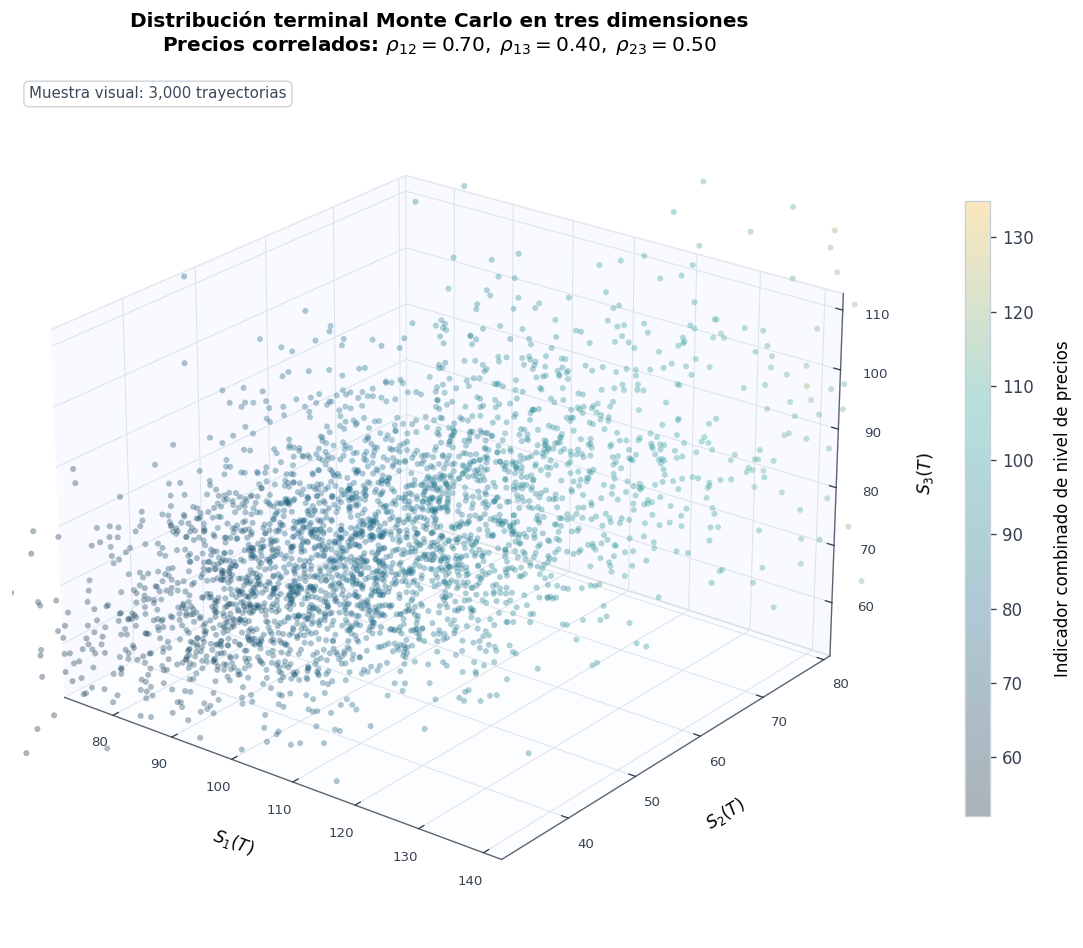

In [30]:
# ── Nube de puntos 3D de los precios terminales ──────────────────────────────
fig = plt.figure(figsize=(10.5, 8.0), facecolor='white')
ax = fig.add_subplot(111, projection='3d')

idx_scatter = np.random.default_rng(7).choice(terminal.shape[0], size=3000, replace=False)
scatter_points = terminal[idx_scatter]
color_values = 0.55 * scatter_points[:, 0] + 0.30 * scatter_points[:, 1] + 0.15 * scatter_points[:, 2]

sc = ax.scatter(
    scatter_points[:, 0],
    scatter_points[:, 1],
    scatter_points[:, 2],
    c=color_values,
    cmap=SCATTER_CMAP,
    s=13,
    alpha=0.34,
    linewidths=0.0,
    depthshade=False,
)

style_3d_axis(ax, elev=24, azim=-52, dist=9.8)
ax.set_title(
    'Distribuci\u00f3n terminal Monte Carlo en tres dimensiones\n'
    r'Precios correlados: $\rho_{12}=0.70,\;\rho_{13}=0.40,\;\rho_{23}=0.50$',
    pad=18,
)
ax.set_xlabel('$S_1(T)$', labelpad=10)
ax.set_ylabel('$S_2(T)$', labelpad=10)
ax.set_zlabel('$S_3(T)$', labelpad=10)

xq = np.quantile(scatter_points[:, 0], [0.01, 0.99])
yq = np.quantile(scatter_points[:, 1], [0.01, 0.99])
zq = np.quantile(scatter_points[:, 2], [0.01, 0.99])
ax.set_xlim(*xq)
ax.set_ylim(*yq)
ax.set_zlim(*zq)

cbar = fig.colorbar(sc, ax=ax, pad=0.08, shrink=0.72, aspect=24)
cbar.set_label('Indicador combinado de nivel de precios', rotation=90, labelpad=12)
cbar.outline.set_edgecolor('#C7D0D9')

ax.text2D(
    0.02,
    0.98,
    f'Muestra visual: {len(idx_scatter):,} trayectorias',
    transform=ax.transAxes,
    fontsize=9,
    color='#3A4A5A',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#D0D7DE', alpha=0.95),
)

plt.tight_layout()
plt.show()

---

## 1. Efecto del Parámetro `n` (Número de Qubits por Activo)

El parámetro $n$ determina la resolución del grid de precios para **cada activo**:

$$N_{\text{bins}} = 2^n \quad \Longrightarrow \quad N_{\text{joint}} = (2^n)^d = 2^{n \cdot d}$$

Para $d=3$ activos, la cuadrícula conjunta crece **exponencialmente** con $n$:

| $n$ | Bins por activo | Estados conjuntos $N_{\text{joint}}$ |
|-----|----------------|--------------------------------------|
| 2   | 4              | 64                                   |
| 3   | 8              | 512                                  |
| 4   | 16             | 4 096                                |
| 5   | 32             | 32 768                               |

Las visualizaciones muestran las **distribuciones marginales bivariantes** $\hat{P}(S_i, S_j)$ obtenidas sumando sobre el tercer activo: esto es equivalente a proyectar la distribución conjunta tridimensional sobre cada plano coordenado.

**Observación clave**: al aumentar $n$, el intervalo de precios se mantiene fijo y solo aumenta la granularidad — el mismo intervalo se subdivide en más celdas.

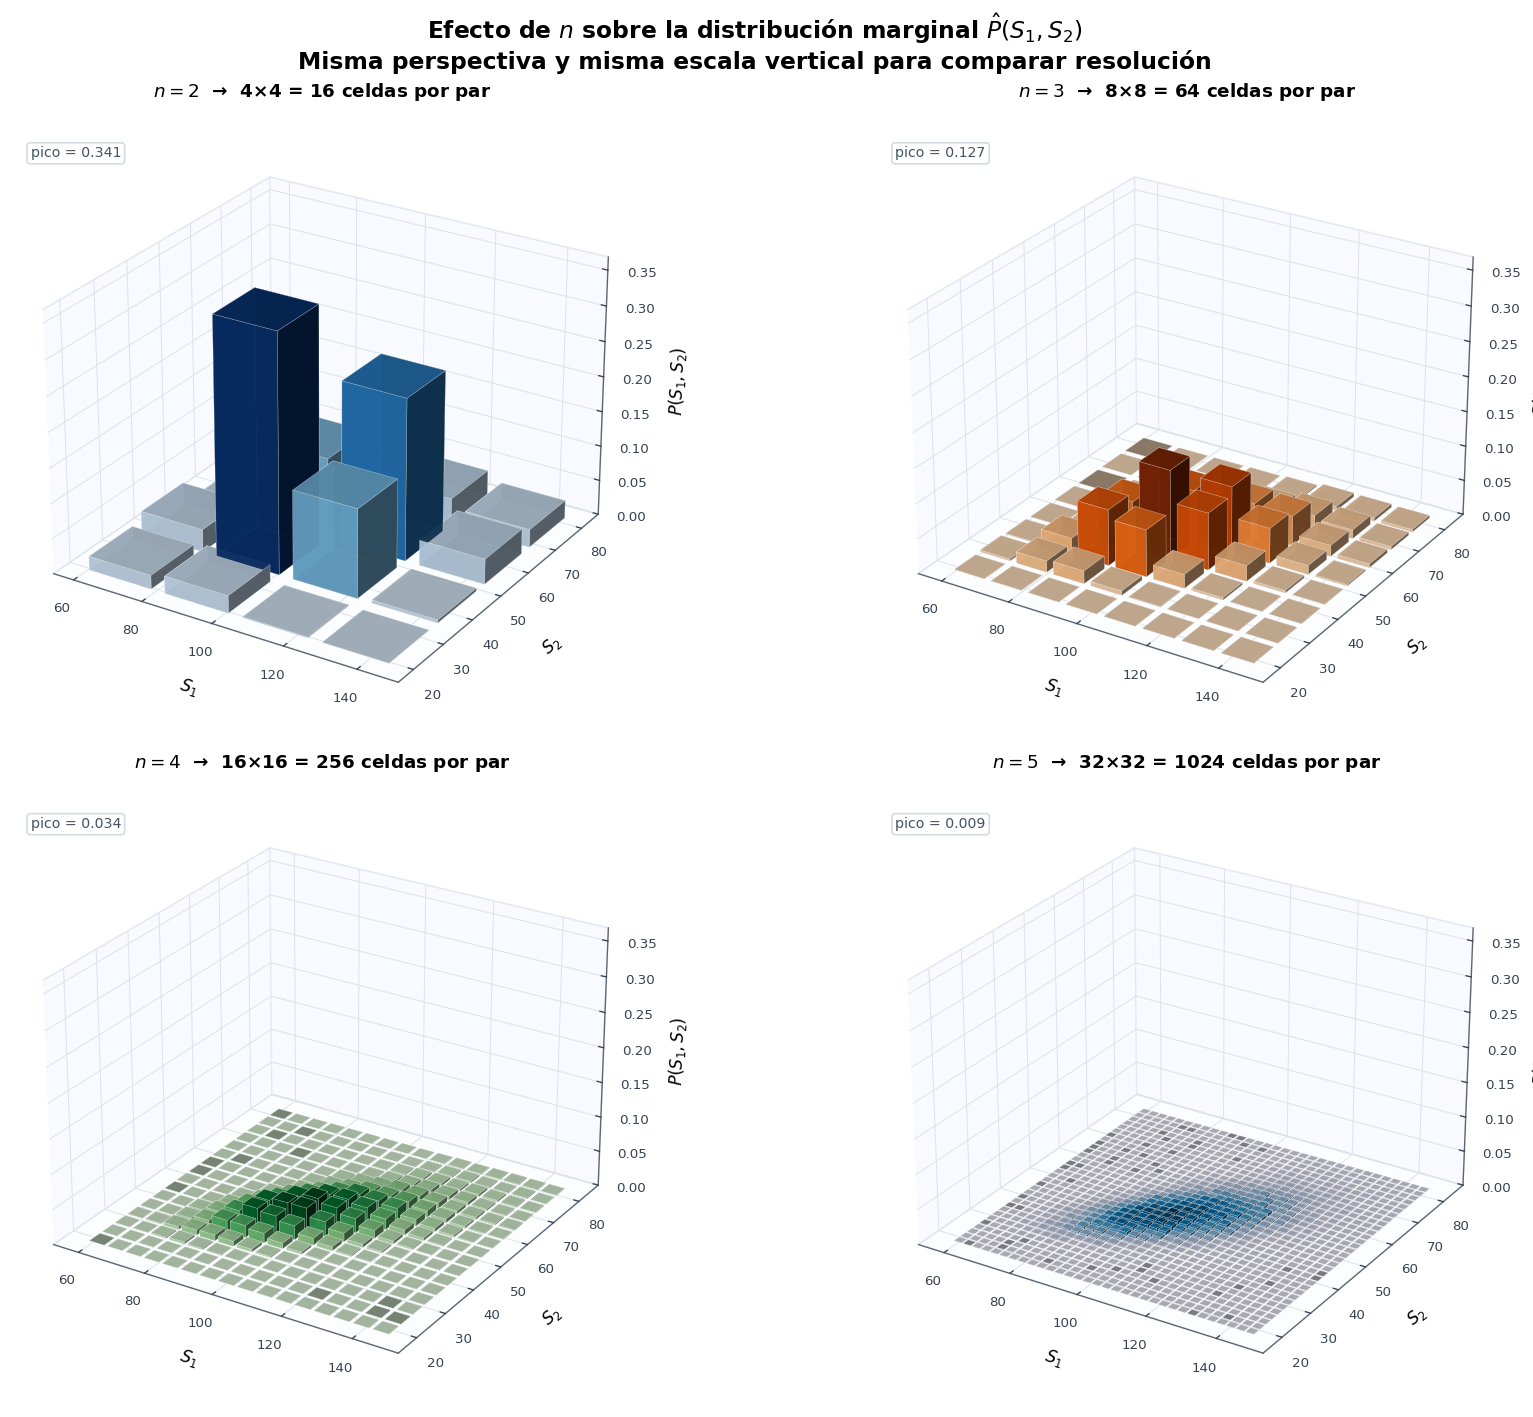

OBSERVACIÓN: Refinamiento uniforme en el intervalo de precios fijo
Al aumentar n, el intervalo [μ−3σ, μ+3σ] se subdivide más finamente.
La distribución discreta converge a una superficie más suave y mejor resuelta.


In [31]:
# ── Comparativa: marginal P(S₁, S₂) para distintos valores de n ─────────────
n_values = [2, 3, 4, 5]
palettes_n = ['blue', 'orange', 'green', 'purple']
plots_n = []

for n in n_values:
    grid_n, P_n = grid_and_prob_tensor_multiasset(S_by_time, n_bits=[n, n, n])
    N = 2 ** n
    P3d = P_n[-1].reshape(N, N, N)
    P12 = P3d.sum(axis=2)
    plots_n.append((n, N, grid_n.rep_list[0], grid_n.rep_list[1], P12))

z_lim_n = 1.08 * max(P12.max() for _, _, _, _, P12 in plots_n)

fig = plt.figure(figsize=(16, 12), facecolor='white')
fig.suptitle(
    r'Efecto de $n$ sobre la distribución marginal $\hat{P}(S_1, S_2)$'
    '\nMisma perspectiva y misma escala vertical para comparar resolución',
    fontsize=14,
    fontweight='bold',
    y=0.98,
)

for idx, ((n, N, s1, s2, P12), palette) in enumerate(zip(plots_n, palettes_n)):
    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')
    bar3d_marginal(ax, s1, s2, P12, palette=palette, zlim=z_lim_n)
    ax.set_title(f'$n={n}$  →  {N}×{N} = {N * N} celdas por par', fontsize=11, pad=10)
    ax.set_xlabel('$S_1$', labelpad=6)
    ax.set_ylabel('$S_2$', labelpad=6)
    ax.set_zlabel('$P(S_1,S_2)$', labelpad=6)
    ax.text2D(
        0.03,
        0.93,
        f'pico = {P12.max():.3f}',
        transform=ax.transAxes,
        fontsize=8.5,
        color='#425466',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#D0D7DE', alpha=0.9),
    )

plt.tight_layout()
plt.show()

print('=' * 65)
print('OBSERVACIÓN: Refinamiento uniforme en el intervalo de precios fijo')
print('=' * 65)
print('Al aumentar n, el intervalo [μ−3σ, μ+3σ] se subdivide más finamente.')
print('La distribución discreta converge a una superficie más suave y mejor resuelta.')

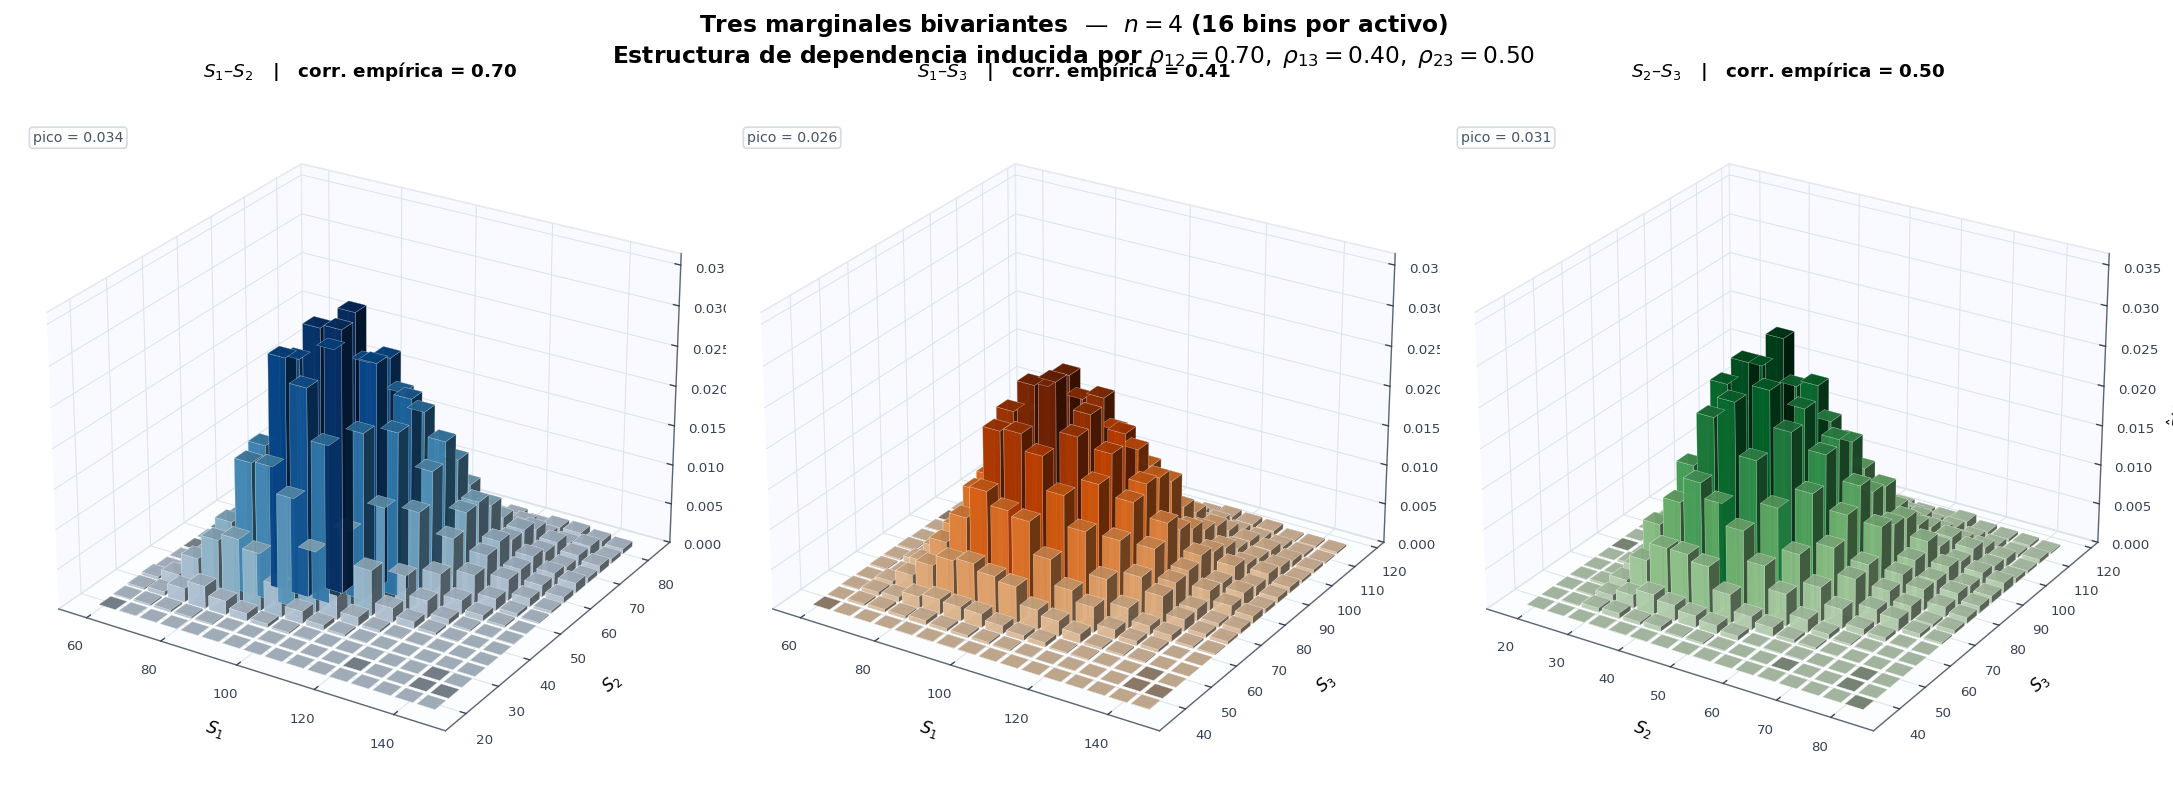

In [32]:
# ── Las tres marginales bivariantes para n = 4 ──────────────────────────────
# P3d[i,j,k] = P(S₁ en bin i, S₂ en bin j, S₃ en bin k)
# Marginal P(S₁,S₂) = sum_k P3d[i,j,k]  →  P3d.sum(axis=2)
# Marginal P(S₁,S₃) = sum_j P3d[i,j,k]  →  P3d.sum(axis=1)
# Marginal P(S₂,S₃) = sum_i P3d[i,j,k]  →  P3d.sum(axis=0)

n_ref = 4
N_ref = 2 ** n_ref
grid_r, P_r = grid_and_prob_tensor_multiasset(S_by_time, n_bits=[n_ref, n_ref, n_ref])
P3d_r = P_r[-1].reshape(N_ref, N_ref, N_ref)

marginals = [
    (P3d_r.sum(axis=2), grid_r.rep_list[0], grid_r.rep_list[1], '$S_1$', '$S_2$', r'$\hat{P}(S_1,S_2)$', 'blue', 0, 1),
    (P3d_r.sum(axis=1), grid_r.rep_list[0], grid_r.rep_list[2], '$S_1$', '$S_3$', r'$\hat{P}(S_1,S_3)$', 'orange', 0, 2),
    (P3d_r.sum(axis=0), grid_r.rep_list[1], grid_r.rep_list[2], '$S_2$', '$S_3$', r'$\hat{P}(S_2,S_3)$', 'green', 1, 2),
]

zmax_ref = max(P_ij.max() for P_ij, *_ in marginals) * 1.08

fig = plt.figure(figsize=(18, 6.8), facecolor='white')
fig.suptitle(
    f'Tres marginales bivariantes  —  $n = {n_ref}$ ({N_ref} bins por activo)\n'
    r'Estructura de dependencia inducida por $\rho_{12}=0.70,\;\rho_{13}=0.40,\;\rho_{23}=0.50$',
    fontsize=14,
    fontweight='bold',
    y=0.98,
)

for k, (P_ij, si, sj, lxi, lxj, lzi, palette, ai, aj) in enumerate(marginals):
    corr_emp = np.corrcoef(terminal[:, ai], terminal[:, aj])[0, 1]
    ax = fig.add_subplot(1, 3, k + 1, projection='3d')
    bar3d_marginal(ax, si, sj, P_ij, palette=palette, zlim=zmax_ref)
    ax.set_xlabel(lxi, labelpad=6)
    ax.set_ylabel(lxj, labelpad=6)
    ax.set_zlabel(lzi, labelpad=7)
    ax.set_title(f'{lxi}–{lxj}   |   corr. empírica = {corr_emp:.2f}', fontsize=11, pad=10)
    ax.text2D(
        0.03,
        0.93,
        f'pico = {P_ij.max():.3f}',
        transform=ax.transAxes,
        fontsize=8.5,
        color='#425466',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#D0D7DE', alpha=0.9),
    )

plt.tight_layout()
plt.show()

---

## 2. Efecto del Parámetro `n_σ` (Anchura del Soporte)

El parámetro $n_\sigma$ controla el **intervalo de truncación** del soporte de cada activo:

$$[S_k^{\min},\, S_k^{\max}] = [\hat\mu_k - n_\sigma\,\hat\sigma_k,\; \hat\mu_k + n_\sigma\,\hat\sigma_k]$$

Con $n$ fijo, el número de bins no cambia: lo que varía es el **ancho de cada celda**.

| $n_\sigma$ | Cobertura aprox. (por activo) | Anchura de celda | Captura de colas |
|------|-------------------------------|------------------|-----------------|
| 2    | ~95.4 %                       | Fina             | Baja             |
| 3    | ~99.7 %                       | Media            | Media            |
| 4    | ~99.99 %                      | Gruesa           | Alta             |
| 5    | ~99.9999 %                    | Muy gruesa       | Muy alta         |

**Compromiso clave**: un $n_\sigma$ mayor captura más escenarios extremos, pero dilata las celdas y reduce la resolución dentro del soporte principal. Esto se observa claramente en las visualizaciones 3D: el soporte se expande pero la distribución discreta se "aplana".

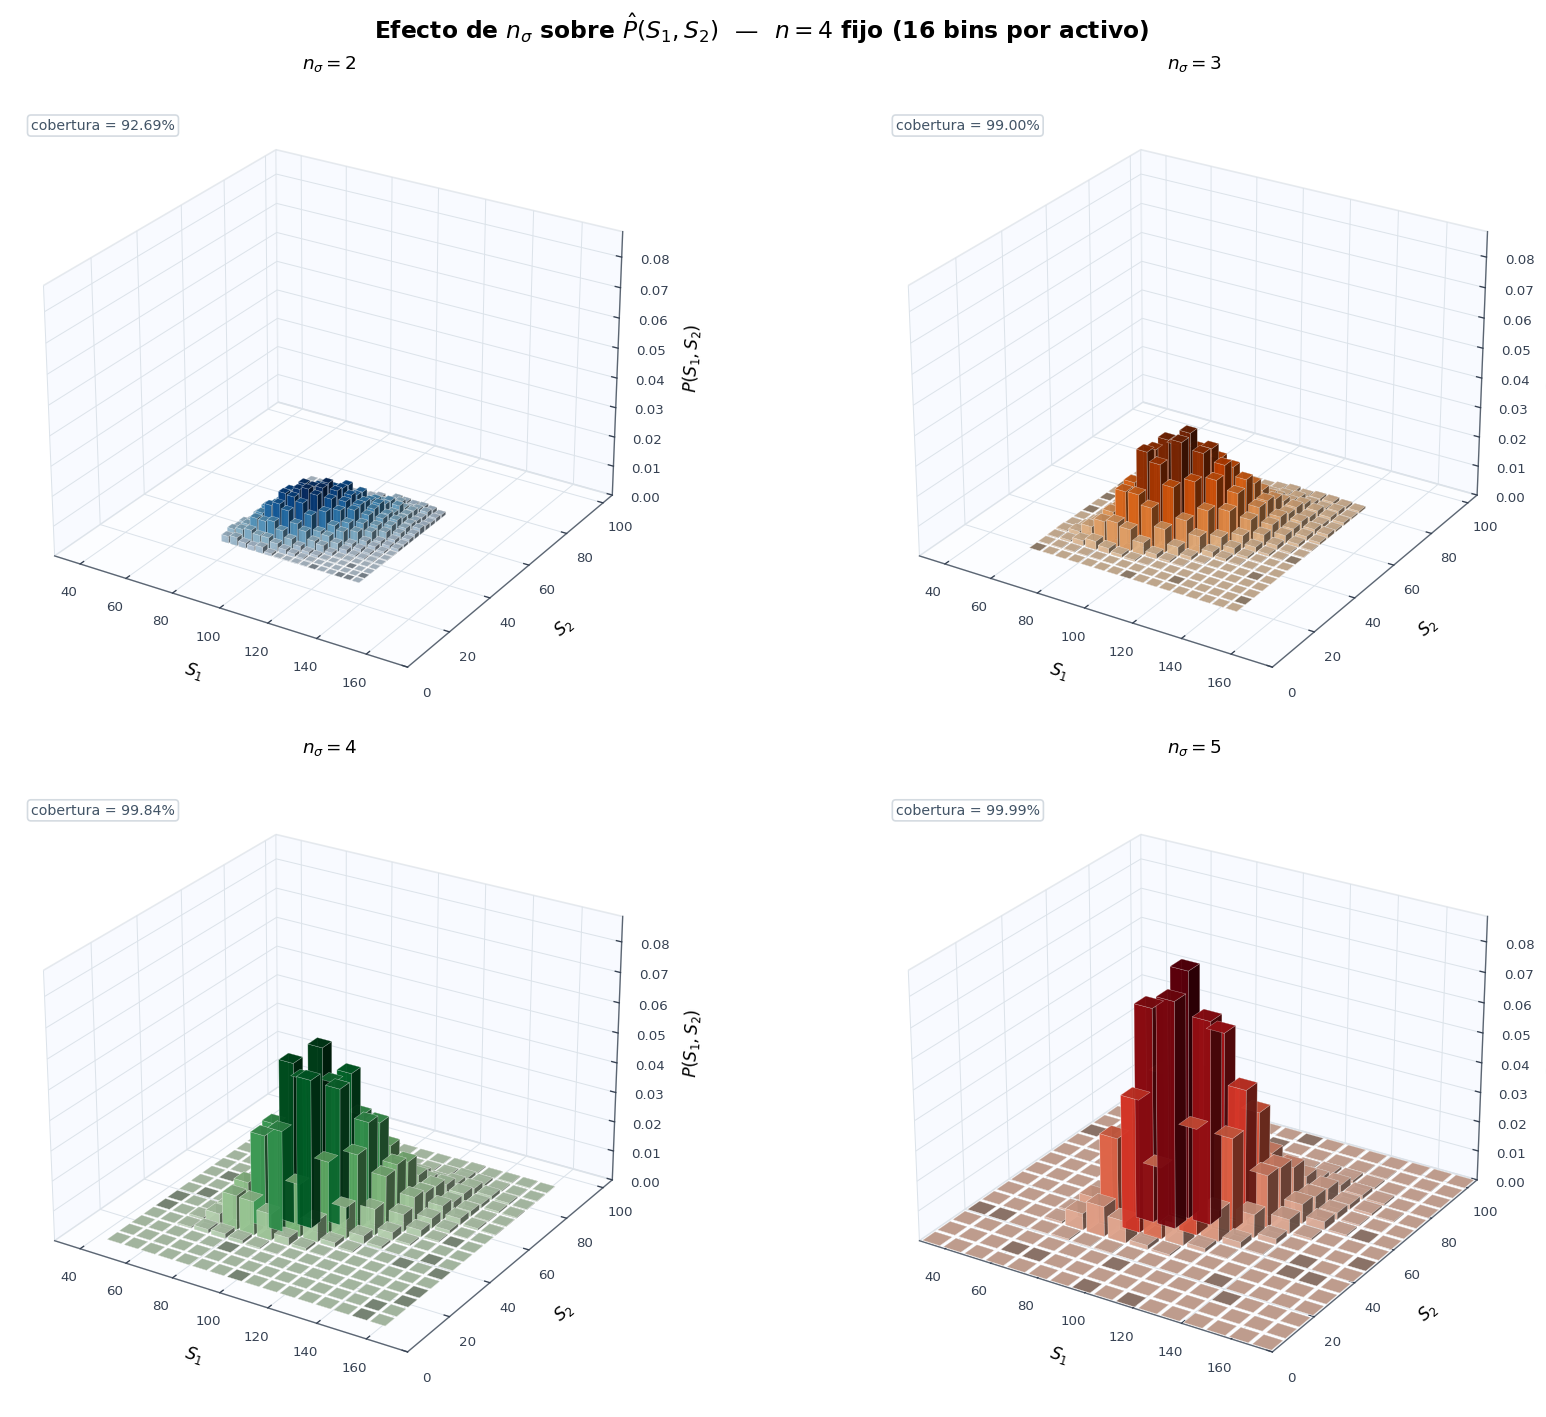

OBSERVACIÓN: Compromiso cobertura vs. resolución
n_sigma grande: soporte amplio, celdas gruesas, distribución más extendida.
n_sigma pequeño: alta resolución, pero pérdida de probabilidad en las colas.


In [33]:
# ── Marginal P(S₁, S₂) para distintos n_sigma  (n = 4 fijo) ─────────────────
n_sigma_values = [2, 3, 4, 5]
palettes_sigma = ['blue', 'orange', 'green', 'red']
n_fixed = 4
N_fixed = 2 ** n_fixed

# Rango global para comparar los ejes X–Y entre subplots
grids_sigma, x_all, y_all, z_all = [], [], [], []
for n_sigma in n_sigma_values:
    g, P = grid_and_prob_tensor_multiasset(S_by_time, n_bits=[n_fixed, n_fixed, n_fixed], n_sigma=n_sigma)
    P3d_sigma = P[-1].reshape(N_fixed, N_fixed, N_fixed)
    P12_sigma = P3d_sigma.sum(axis=2)
    grids_sigma.append((g, P12_sigma))
    x_all.extend([g.edges_list[0][0], g.edges_list[0][-1]])
    y_all.extend([g.edges_list[1][0], g.edges_list[1][-1]])
    z_all.append(P12_sigma.max())

x_lim = (min(x_all), max(x_all))
y_lim = (min(y_all), max(y_all))
z_lim = max(z_all) * 1.08

fig = plt.figure(figsize=(16, 12), facecolor='white')
fig.suptitle(
    r'Efecto de $n_\sigma$ sobre $\hat{P}(S_1, S_2)$  —  $n = 4$ fijo (16 bins por activo)',
    fontsize=14,
    fontweight='bold',
    y=0.98,
)

for idx, ((g_s, P12_s), n_sigma, palette) in enumerate(zip(grids_sigma, n_sigma_values, palettes_sigma)):
    s1_s = g_s.rep_list[0]
    s2_s = g_s.rep_list[1]

    in_x = (terminal[:, 0] >= g_s.edges_list[0][0]) & (terminal[:, 0] <= g_s.edges_list[0][-1])
    in_y = (terminal[:, 1] >= g_s.edges_list[1][0]) & (terminal[:, 1] <= g_s.edges_list[1][-1])
    cov = 100.0 * np.mean(in_x & in_y)

    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')
    bar3d_marginal(ax, s1_s, s2_s, P12_s, palette=palette, zlim=z_lim)
    ax.set_xlabel('$S_1$', labelpad=6)
    ax.set_ylabel('$S_2$', labelpad=6)
    ax.set_zlabel('$P(S_1,S_2)$', labelpad=6)
    ax.set_xlim(*x_lim)
    ax.set_ylim(*y_lim)
    ax.set_title(f'$n_\\sigma = {n_sigma}$', fontsize=11, pad=10)
    ax.text2D(
        0.03,
        0.93,
        f'cobertura = {cov:.2f}%',
        transform=ax.transAxes,
        fontsize=8.5,
        color='#425466',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#D0D7DE', alpha=0.9),
    )

plt.tight_layout()
plt.show()

print('=' * 65)
print('OBSERVACIÓN: Compromiso cobertura vs. resolución')
print('=' * 65)
print('n_sigma grande: soporte amplio, celdas gruesas, distribución más extendida.')
print('n_sigma pequeño: alta resolución, pero pérdida de probabilidad en las colas.')

---

## 3. Efecto de la Correlación sobre la Distribución Discreta

La correlación entre activos deforma la distribución conjunta $P(S_i, S_j)$ respecto al caso independiente:

- **Activos independientes** ($\rho_{ij} = 0$): la distribución bivariante factoriza como $P(S_i, S_j) = P(S_i)\,P(S_j)$, generando una superficie "radialmente" simétrica.
- **Activos correlados positivamente**: la masa de probabilidad se concentra a lo largo de la diagonal principal, creando una **cresta inclinada** visible en los gráficos 3D.
- **Activos correlados negativamente**: la masa se concentra en la anti-diagonal.

Esta sección compara las tres marginales bivariantes con dos escenarios:
1. Correlación original $(\rho_{12}=0.70,\, \rho_{13}=0.40,\, \rho_{23}=0.50)$
2. Sin correlación $(\rho = I_3)$

C:\Users\guilb\AppData\Local\Temp\ipykernel_23468\3608330573.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = BAR_CMAPS.get(palette, cm.get_cmap('Blues'))


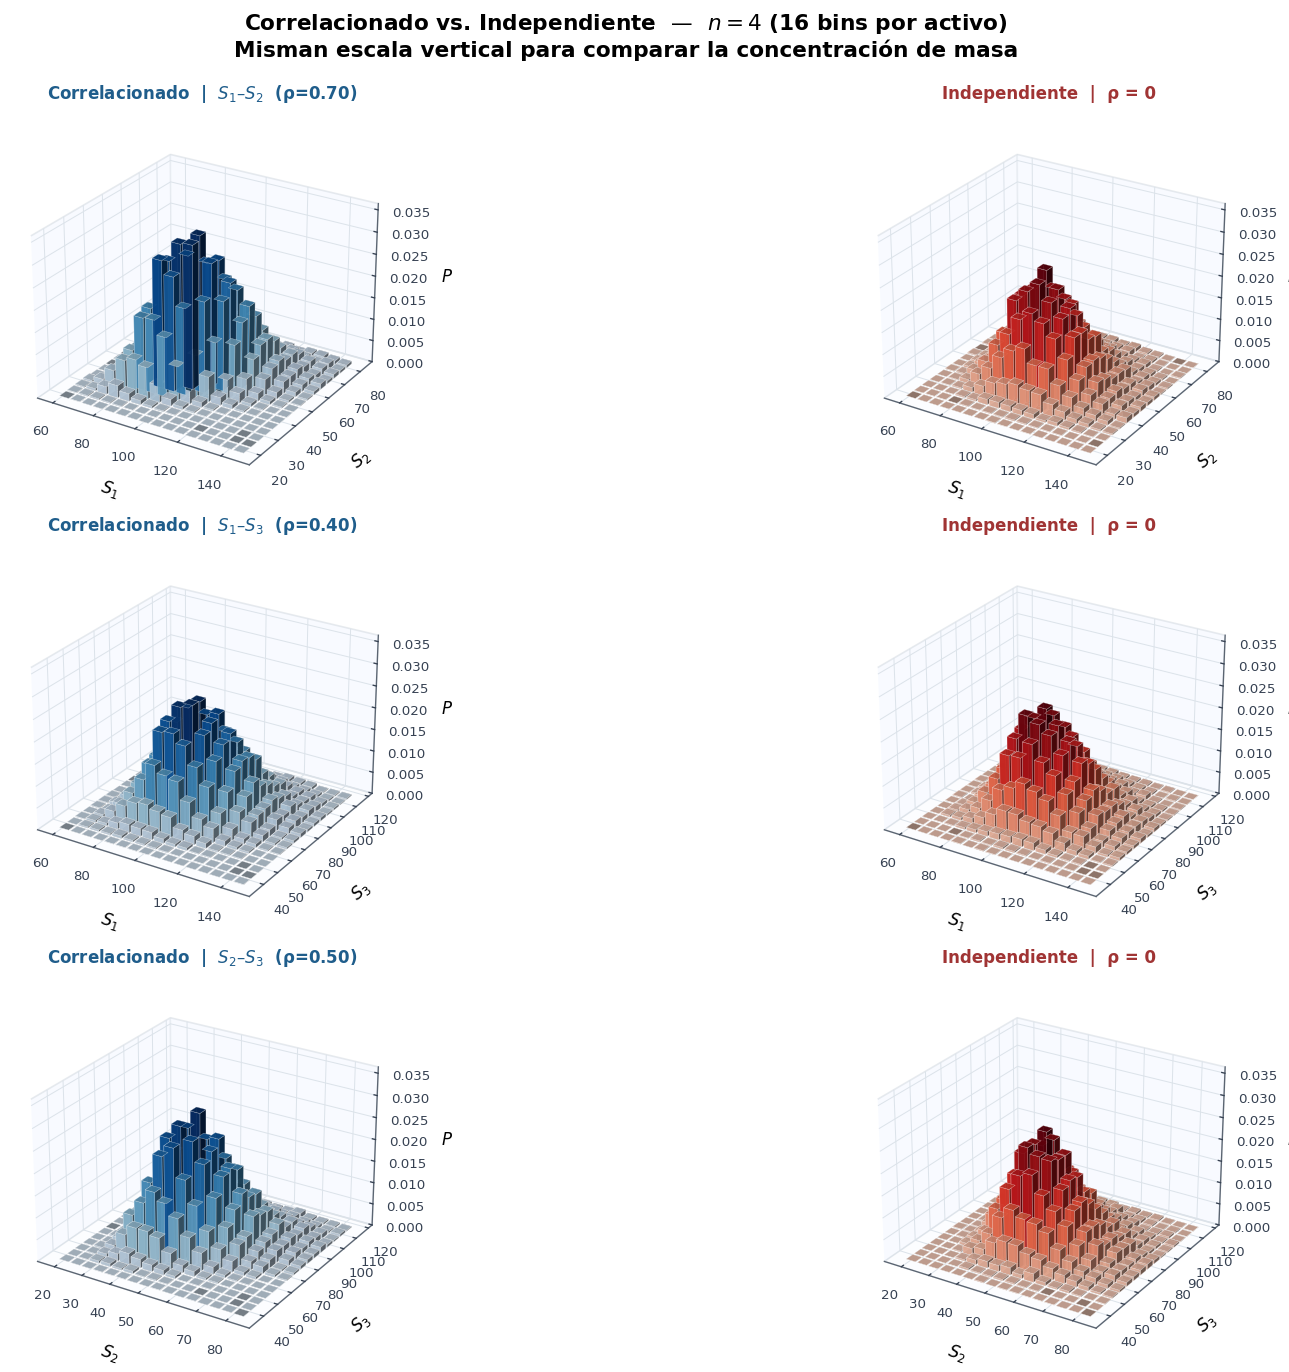

OBSERVACIÓN: Efecto de la correlación
Correlacionado: masa concentrada en la diagonal → cresta inclinada.
Independiente : masa distribuida con mayor simetría → relieve más difuso.


In [21]:
# ── Simulación sin correlación (rho = I₃) ───────────────────────────────────
rho_id = np.eye(3)
Z_unc = np.random.default_rng(42).standard_normal(size=(N_paths, M, 3))

S_raw_unc = simulate_multi_asset_gbm(
    S0=S0, mu=mu, sigma=sigma, rho=rho_id, t=t, Z=Z_unc,
    antithetic=True, moment_match=False,
    replications=1, replication_seed=12345, pathwise=True,
)
S_by_time_unc = [S_raw_unc[:, i, :] for i in range(S_raw_unc.shape[1])]
terminal_unc = S_by_time_unc[-1]

n_comp = 4
N_comp = 2 ** n_comp

grid_c, P_c = grid_and_prob_tensor_multiasset(S_by_time, n_bits=[n_comp] * 3)
grid_unc, P_unc = grid_and_prob_tensor_multiasset(S_by_time_unc, n_bits=[n_comp] * 3)

P3d_c = P_c[-1].reshape(N_comp, N_comp, N_comp)
P3d_unc = P_unc[-1].reshape(N_comp, N_comp, N_comp)

P12_c = P3d_c.sum(axis=2)
P12_unc = P3d_unc.sum(axis=2)
P13_c = P3d_c.sum(axis=1)
P13_unc = P3d_unc.sum(axis=1)
P23_c = P3d_c.sum(axis=0)
P23_unc = P3d_unc.sum(axis=0)

pair_labels = ['$S_1$–$S_2$  (ρ=0.70)', '$S_1$–$S_3$  (ρ=0.40)', '$S_2$–$S_3$  (ρ=0.50)']
P_corr_list = [P12_c, P13_c, P23_c]
P_unc_list = [P12_unc, P13_unc, P23_unc]
rep_pairs = [
    (grid_c.rep_list[0], grid_c.rep_list[1]),
    (grid_c.rep_list[0], grid_c.rep_list[2]),
    (grid_c.rep_list[1], grid_c.rep_list[2]),
]
lx_pairs = [('$S_1$', '$S_2$'), ('$S_1$', '$S_3$'), ('$S_2$', '$S_3$')]
z_lim_comp = 1.08 * max(max(P.max() for P in P_corr_list), max(P.max() for P in P_unc_list))

fig = plt.figure(figsize=(18, 11.5), facecolor='white')
fig.suptitle(
    f'Correlacionado vs. Independiente  —  $n = {n_comp}$ ({N_comp} bins por activo)\n'
    'Misman escala vertical para comparar la concentración de masa',
    fontsize=13,
    fontweight='bold',
    y=0.99,
)

for row, (P_co, P_un, reps, lxs, plabel) in enumerate(zip(P_corr_list, P_unc_list, rep_pairs, lx_pairs, pair_labels)):
    si, sj = reps
    lxi, lxj = lxs

    ax_l = fig.add_subplot(3, 2, 2 * row + 1, projection='3d')
    bar3d_marginal(ax_l, si, sj, P_co, palette='blue', zlim=z_lim_comp)
    ax_l.set_xlabel(lxi, labelpad=5)
    ax_l.set_ylabel(lxj, labelpad=5)
    ax_l.set_zlabel('$P$', labelpad=5)
    ax_l.set_title(f'Correlacionado  |  {plabel}', fontsize=10, color='#1F5D8B', pad=10)

    ax_r = fig.add_subplot(3, 2, 2 * row + 2, projection='3d')
    bar3d_marginal(ax_r, si, sj, P_un, palette='red', alpha=0.90, zlim=z_lim_comp)
    ax_r.set_xlabel(lxi, labelpad=5)
    ax_r.set_ylabel(lxj, labelpad=5)
    ax_r.set_zlabel('$P$', labelpad=5)
    ax_r.set_title('Independiente  |  ρ = 0', fontsize=10, color='#A03434', pad=10)

plt.tight_layout()
plt.show()

print('=' * 65)
print('OBSERVACIÓN: Efecto de la correlación')
print('=' * 65)
print('Correlacionado: masa concentrada en la diagonal → cresta inclinada.')
print('Independiente : masa distribuida con mayor simetría → relieve más difuso.')

---

## Resumen: Guía de Selección de Parámetros

### Tabla de compromiso para $d = 3$ activos

| Parámetro | Aumentar → | Efecto positivo | Coste |
|-----------|-----------|-----------------|-------|
| $n$       | más bits por activo | mayor resolución en cada plano marginal | $N_{\text{joint}} = 2^{3n}$ crece exponencialmente |
| $n_\sigma$ | soporte más amplio | captura de colas; menor pérdida de probabilidad | celdas más grandes; menor granularidad |

### Recomendaciones prácticas

- **Prototipado / prueba de concepto**: $n = 3$ (512 estados), $n_\sigma = 3$
- **Uso estándar**: $n = 4$ (4 096 estados), $n_\sigma = 3$–$4$
- **Alta precisión**: $n = 5$ (32 768 estados), $n_\sigma = 4$; requiere recursos clásicos y cuánticos considerables

### Impacto de la correlación en la discretización

La correlación **no afecta** al número de celdas ni al soporte de cada activo — estos se determinan individualmente por las estadísticas marginales. Sin embargo, la correlación **sí redistribuye la masa de probabilidad** dentro de la cuadrícula conjunta: los activos con alta correlación positiva concentran probabilidad en la diagonal, lo que puede causar celdas fuera de la diagonal con densidad casi nula. Tenerlo en cuenta es crucial para la asignación eficiente de qubits en algoritmos cuánticos de preparación de estado.